# 08. Análisis exploratorio, cobertura de ubicación, calidad de datos y correlación de hoteles en Barcelona

En este notebook se lleva a cabo el análisis exploratorio integral de los hoteles del municipio de Barcelona para comprender el comportamiento de sus características clave antes de proceder a la imputación de precios y clustering.

## Objetivos del análisis
1. **Análisis de ubicación:** Evaluar la cobertura y distribución espacial de las variables de localización (`barrio`, `codigo_postal`, `lat_final`, `lon_final`, `distancia_centro_km`).
2. **Calidad de datos:** Identificar valores nulos, registros duplicados y detectar valores atípicos (*outliers*) mediante el rango intercuartílico (IQR).
3. **Distribución y comportamiento:** Inspeccionar las distribuciones de `precio_noche`, `plazas`, `habitaciones` y `categoria_num`, evaluando la transformación logarítmica.
4. **Análisis de correlación:** Medir la asociación lineal (Pearson) y no lineal (Spearman) entre las características del hotel y el precio por noche.
5. **Varianza explicada (ANOVA $\eta^2$):** Cuantificar la capacidad explicativa del Barrio y Código Postal sobre la variabilidad del precio.
6. **Categorías por estrellas:** Analizar la relación entre la categoría oficial de estrellas y las tarifas.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Configuración de gráficos
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# Determinación dinámica de la raíz del proyecto
RAIZ = Path.cwd()
while not (RAIZ / 'data').exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
if not (RAIZ / 'data').exists():
    RAIZ = Path('../..')

# Carga directa del dataset unificado de Barcelona preparado en data/processed
RUTA_CSV = RAIZ / 'data' / 'processed' / 'hoteles_bcn_preparados.csv'
df = pd.read_csv(RUTA_CSV)

# Distancia euclídea aproximada a Plaça Catalunya (41.3870, 2.1700) en km
df['distancia_centro_km'] = np.sqrt((df['lat_final'] - 41.3870)**2 + (df['lon_final'] - 2.1700)**2) * 111.0

print(f'Total de hoteles en el dataset preparado de Barcelona: {len(df)}')
print(f'Hoteles con precio raspado disponible: {df["precio_noche"].notna().sum()}')

Total de hoteles en el dataset preparado de Barcelona: 768
Hoteles con precio raspado disponible: 476


## 1. Cobertura y análisis geográfico: Barrio, Código Postal y Geolocalización
Evaluación de la tasa de completitud de las variables territoriales e inspección de las zonas con mayor densidad hotelera.

Cobertura general de variables de localización:


,Variable de Ubicación,No Nulos,Nulos,Porcentaje Cobertura (%)
0,Código Postal,767,1,99.9
1,Barrio (enriquecido),766,2,99.7
2,Coordenadas exactas (lat/lon),750,18,97.7


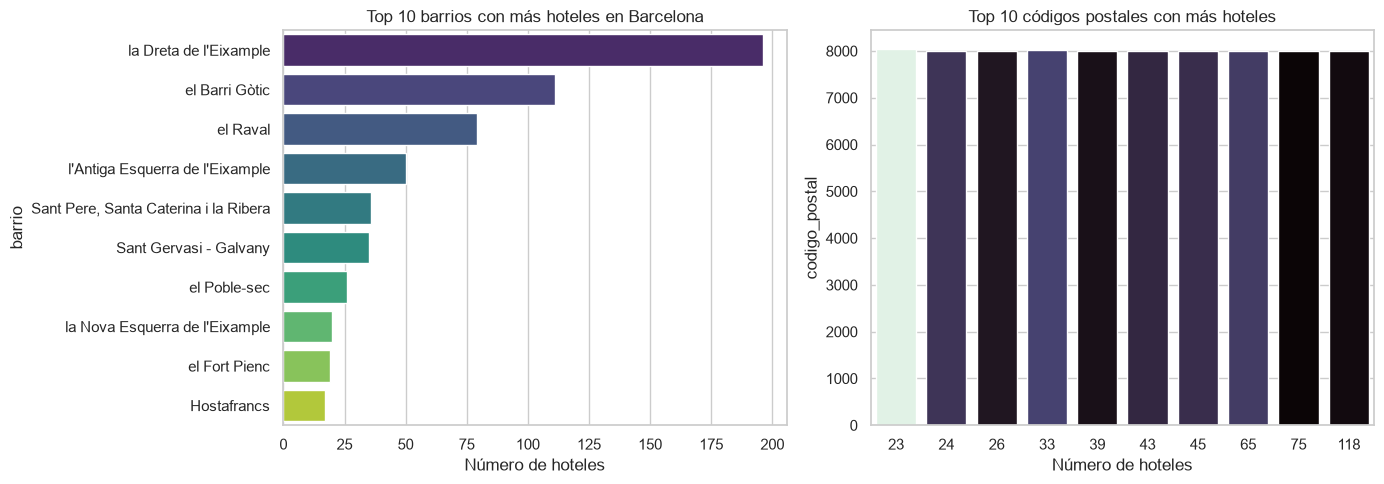

In [10]:
# Tabla de cobertura de datos de ubicación
cobertura = pd.DataFrame({
    'Variable de Ubicación': ['Código Postal', 'Barrio (enriquecido)', 'Coordenadas exactas (lat/lon)'],
    'No Nulos': [df['codigo_postal'].notna().sum(), df['barrio'].notna().sum(), df['lat_final'].notna().sum()],
    'Nulos': [df['codigo_postal'].isna().sum(), df['barrio'].isna().sum(), df['lat_final'].isna().sum()],
    'Porcentaje Cobertura (%)': [
        round(df['codigo_postal'].notna().mean() * 100, 1),
        round(df['barrio'].notna().mean() * 100, 1),
        round(df['lat_final'].notna().mean() * 100, 1)
    ]
})
print('Cobertura general de variables de localización:')
display(cobertura)

# Top 10 barrios y códigos postales con más hoteles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_barrios = df['barrio'].value_counts().head(10)
sns.barplot(x=top_barrios.values, y=top_barrios.index, ax=axes[0], hue=top_barrios.index, palette='viridis', legend=False)
axes[0].set_title('Top 10 barrios con más hoteles en Barcelona')
axes[0].set_xlabel('Número de hoteles')

top_cp = df['codigo_postal'].value_counts().head(10)
sns.barplot(x=top_cp.values, y=top_cp.index, ax=axes[1], hue=top_cp.index, palette='mako', legend=False)
axes[1].set_title('Top 10 códigos postales con más hoteles')
axes[1].set_xlabel('Número de hoteles')
plt.tight_layout()
plt.show()

## 2. Análisis de calidad de datos: Nulos, Duplicados y Outliers
Auditoría sistemática de valores ausentes, comprobación de registros duplicados e identificación de valores extremos (*outliers*) en las variables numéricas.

Resumen de calidad de datos y nulos en variables finales:


,Variable Consolidada,Nulos,Porcentaje Nulos (%)
0,codigo_postal,1,0.13
7,habitaciones,1,0.13
6,plazas,1,0.13
1,barrio,2,0.26
3,lon_final,18,2.34
2,lat_final,18,2.34
4,distancia_centro_km,18,2.34
8,precio_noche,292,38.02
5,categoria_num,306,39.84


Duplicados por licencia_id: 0
Duplicados por nombre comercial: 8


,Variable,Muestra No Nula,Límite Inferior (IQR),Límite Superior (IQR),Número Outliers,Porcentaje Outliers (%)
0,precio_noche,476,12.65,168.71,33,6.93
1,plazas,767,-174.00,338.00,48,6.26
2,habitaciones,767,-93.75,184.25,46,6.00


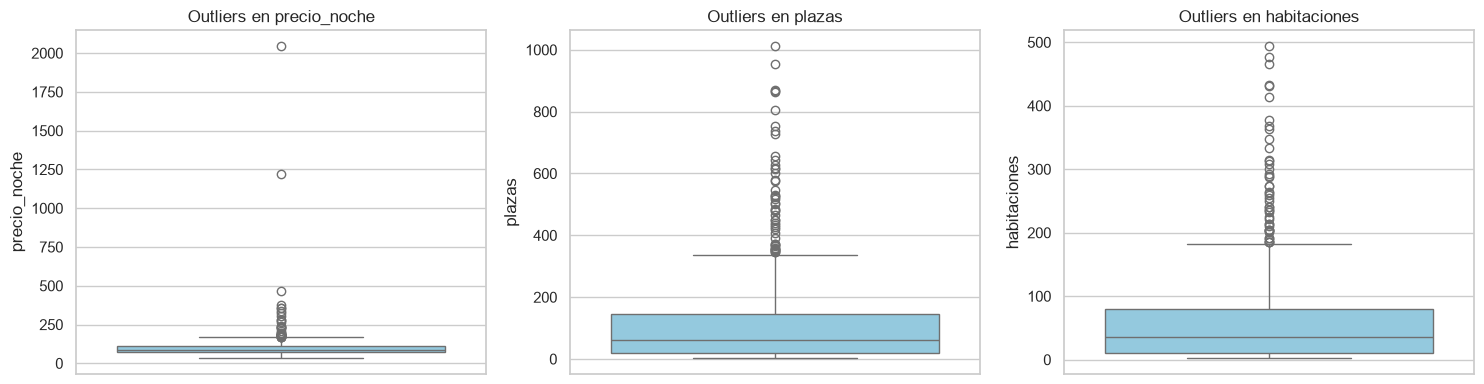

In [11]:
# 1. Análisis de Nulos exclusivo sobre variables consolidadas (excluyendo artefactos crudos del merge)
columnas_consolidadas = [
    'codigo_postal', 'barrio', 'lat_final', 'lon_final', 'distancia_centro_km',
    'categoria_num', 'plazas', 'habitaciones', 'precio_noche'
]
resumen_nulos = pd.DataFrame({
    'Variable Consolidada': columnas_consolidadas,
    'Nulos': df[columnas_consolidadas].isna().sum().values,
    'Porcentaje Nulos (%)': (df[columnas_consolidadas].isna().mean() * 100).round(2).values
}).sort_values('Nulos')

print('Resumen de calidad de datos y nulos en variables finales:')
display(resumen_nulos)

# 2. Verificación de registros duplicados
duplicados_id = df.duplicated(subset=['licencia_id']).sum()
duplicados_nombre = df.duplicated(subset=['nombre_comercial']).sum()
print(f'Duplicados por licencia_id: {duplicados_id}')
print(f'Duplicados por nombre comercial: {duplicados_nombre}')

# 3. Detección de Outliers mediante Rango Intercuartílico (IQR)
def detectar_outliers_iqr(series: pd.Series) -> tuple[pd.Series, float, float]:
    """Calcula la máscara de outliers e intervalos de valla usando 1.5 * IQR."""
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    return (series < lim_inf) | (series > lim_sup), lim_inf, lim_sup

cols_eval = ['precio_noche', 'plazas', 'habitaciones']
res_outliers = []
for c in cols_eval:
    mask_out, inf, sup = detectar_outliers_iqr(df[c])
    num_out = mask_out.sum()
    pct_out = round(num_out / df[c].notna().sum() * 100, 2)
    res_outliers.append({
        'Variable': c,
        'Muestra No Nula': df[c].notna().sum(),
        'Límite Inferior (IQR)': round(inf, 2),
        'Límite Superior (IQR)': round(sup, 2),
        'Número Outliers': num_out,
        'Porcentaje Outliers (%)': pct_out
    })

display(pd.DataFrame(res_outliers))

# Gráficos de caja (Boxplots) para detección visual de outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, c in enumerate(cols_eval):
    sns.boxplot(data=df, y=c, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Outliers en {c}')
plt.tight_layout()
plt.show()

## 3. Comportamiento y distribución de variables clave
Inspección de las estadísticas descriptivas y del sesgo en la distribución de precios, evaluando la transformación a escala logarítmica $\log(1 + \text{precio\_noche})$.

Estadísticos descriptivos del conjunto de hoteles de Barcelona:


,precio_noche,plazas,habitaciones,categoria_num,distancia_centro_km
count,476.00,767.00,767.00,462.00,750.00
mean,105.20,110.03,58.43,3.34,1.76
std,114.20,140.87,71.95,1.16,1.39
min,31.78,2.00,2.00,1.00,0.12
25%,71.18,18.00,10.50,3.00,0.79
50%,86.44,63.00,36.00,4.00,1.28
75%,110.19,146.00,80.00,4.00,2.40
max,2045.24,1012.00,494.00,5.00,9.06


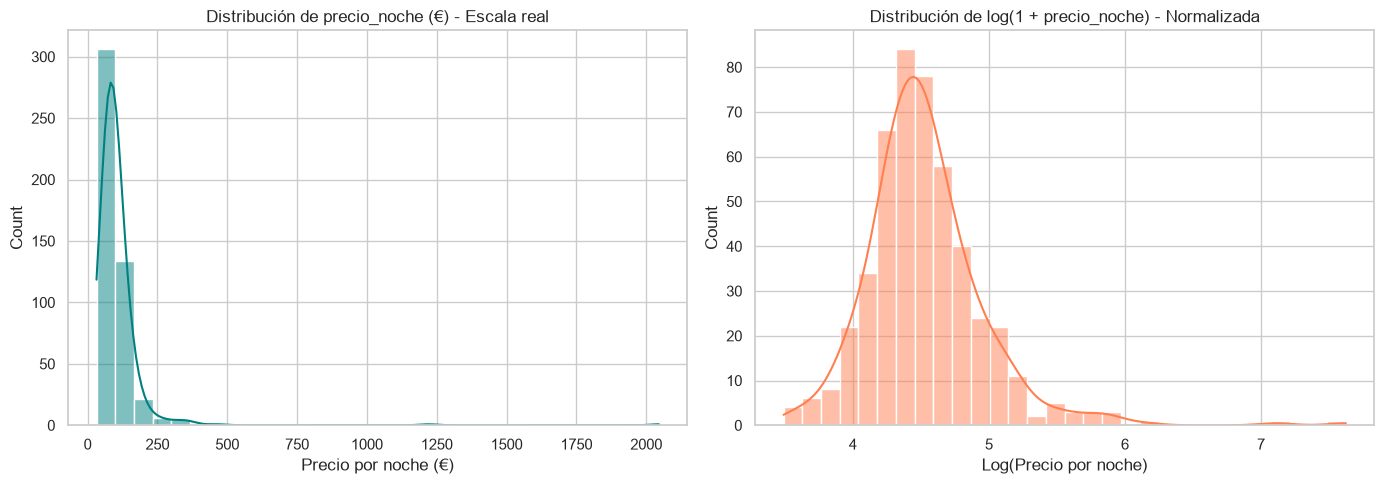

In [12]:
# Estadísticos descriptivos numéricos de las variables consolidadas
vars_num = ['precio_noche', 'plazas', 'habitaciones', 'categoria_num', 'distancia_centro_km']
print('Estadísticos descriptivos del conjunto de hoteles de Barcelona:')
display(df[vars_num].describe().round(2))

# Comparación de la distribución del precio en escala real vs escala logarítmica
sub_precio = df[df['precio_noche'].notna()].copy()
sub_precio['log_precio_noche'] = np.log1p(sub_precio['precio_noche'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(sub_precio['precio_noche'], kde=True, ax=axes[0], color='teal', bins=30)
axes[0].set_title('Distribución de precio_noche (€) - Escala real')
axes[0].set_xlabel('Precio por noche (€)')

sns.histplot(sub_precio['log_precio_noche'], kde=True, ax=axes[1], color='coral', bins=30)
axes[1].set_title('Distribución de log(1 + precio_noche) - Normalizada')
axes[1].set_xlabel('Log(Precio por noche)')
plt.tight_layout()
plt.show()

## 4. Matriz de correlación de Pearson y Spearman con el precio por noche
Análisis de asociación entre la tarifa por noche (`precio_noche` y `log_precio_noche`) y las variables cuantitativas del hotel.

Correlación entre características del hotel y el precio:


,Variable,Pearson (Precio Real),Spearman (Precio Real),Pearson (Log-Precio),Muestra Muestra
0,categoria_num,0.263,0.652,0.554,349
1,habitaciones,0.167,0.397,0.362,476
2,plazas,0.174,0.415,0.371,476
3,lat_final,0.052,0.068,0.024,475
4,lon_final,0.183,0.054,0.162,475
5,distancia_centro_km,0.106,-0.068,0.048,475


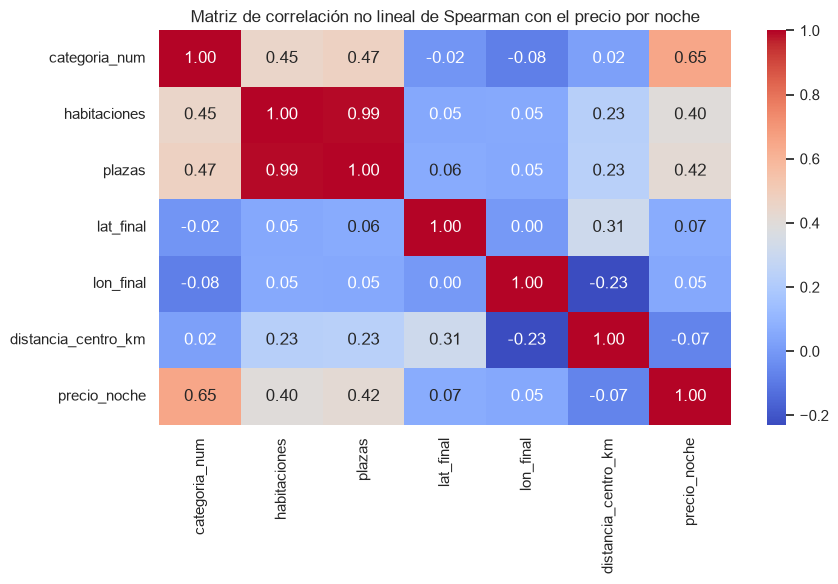

In [13]:
sub = df[df['precio_noche'].notna()].copy()
sub['log_precio_noche'] = np.log1p(sub['precio_noche'])

cols_corr = ['categoria_num', 'habitaciones', 'plazas', 'lat_final', 'lon_final', 'distancia_centro_km']

filas_corr = []
for col in cols_corr:
    valid = sub.dropna(subset=[col, 'precio_noche', 'log_precio_noche'])
    p_real, _ = stats.pearsonr(valid[col], valid['precio_noche'])
    s_real, _ = stats.spearmanr(valid[col], valid['precio_noche'])
    p_log, _ = stats.pearsonr(valid[col], valid['log_precio_noche'])
    filas_corr.append({
        'Variable': col,
        'Pearson (Precio Real)': round(p_real, 3),
        'Spearman (Precio Real)': round(s_real, 3),
        'Pearson (Log-Precio)': round(p_log, 3),
        'Muestra Muestra': len(valid)
    })

print('Correlación entre características del hotel y el precio:')
display(pd.DataFrame(filas_corr))

# Mapa de calor (Heatmap) de correlación de Spearman
plt.figure(figsize=(9, 6))
sns.heatmap(sub[cols_corr + ['precio_noche']].corr(method='spearman'), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación no lineal de Spearman con el precio por noche')
plt.tight_layout()
plt.show()

## 5. Análisis ANOVA de asociación con Código Postal y Barrio
Varianza explicada ($\eta^2$) y contraste de hipótesis $F$ para determinar la relación entre la ubicación cualitativa y el precio.

In [14]:
res_anova = []
for cat_var in ['barrio', 'codigo_postal']:
    valid = sub.dropna(subset=[cat_var, 'log_precio_noche'])
    grupos = [g['log_precio_noche'].values for _, g in valid.groupby(cat_var) if len(g) >= 3]
    f_stat, p_val = stats.f_oneway(*grupos)
    
    ss_total = np.sum((valid['log_precio_noche'] - valid['log_precio_noche'].mean())**2)
    ss_between = sum(len(g) * (np.mean(g) - valid['log_precio_noche'].mean())**2 for g in grupos)
    eta_sq = ss_between / ss_total
    
    res_anova.append({
        'Variable de Ubicación': cat_var,
        'Número de Zonas (N >= 3)': len(grupos),
        'Estadístico F': round(f_stat, 2),
        'p-value': f'{p_val:.3e}',
        'Eta-cuadrado (Varianza explicada)': round(eta_sq, 3)
    })

print('Resultado del análisis ANOVA y varianza explicada (Eta-cuadrado):')
display(pd.DataFrame(res_anova))

Resultado del análisis ANOVA y varianza explicada (Eta-cuadrado):


,Variable de Ubicación,Número de Zonas (N >= 3),Estadístico F,p-value,Eta-cuadrado (Varianza explicada)
0,barrio,26,3.41,1.233e-07,0.159
1,codigo_postal,30,3.31,4.537e-08,0.175


## 6. Distribución del precio por noche según la categoría oficial de estrellas

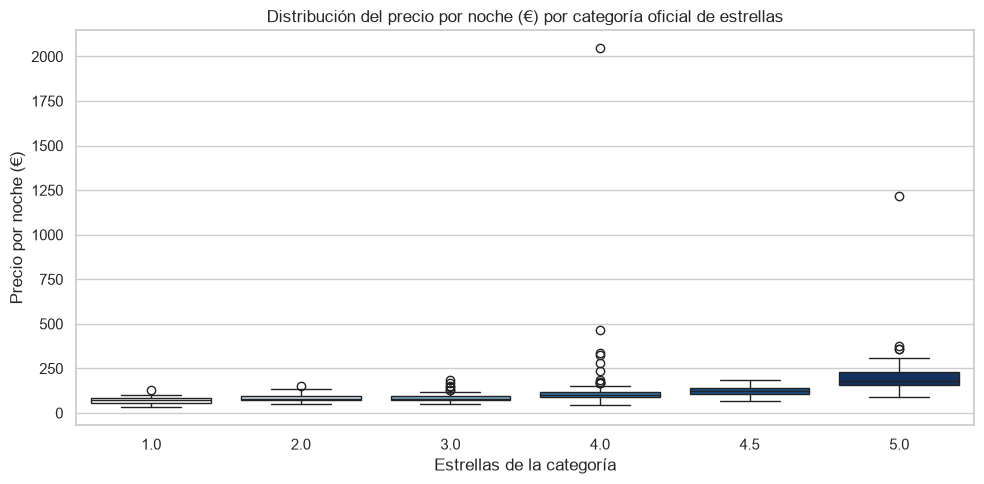

Resumen estadístico del precio por categoría oficial:


,count,mean,median,std,min,max
categoria_num,,,,,,
1.0,30,71.88,70.13,20.53,31.78,131.75
2.0,29,83.45,79.87,22.83,49.55,149.50
3.0,101,85.42,80.92,22.30,52.63,187.59
4.0,122,127.40,100.47,183.06,45.24,2045.24
4.5,30,122.86,121.48,25.63,66.90,184.50
5.0,37,223.67,180.76,181.25,89.96,1219.25


In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=sub, x='categoria_num', y='precio_noche', hue='categoria_num', palette='Blues', legend=False)
plt.title('Distribución del precio por noche (€) por categoría oficial de estrellas')
plt.xlabel('Estrellas de la categoría')
plt.ylabel('Precio por noche (€)')
plt.tight_layout()
plt.show()

resumen_estrellas = sub.groupby('categoria_num')['precio_noche'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
print('Resumen estadístico del precio por categoría oficial:')
display(resumen_estrellas)

## Resumen de hallazgos y conclusiones de la exploración

### Preguntas y respuestas
- **¿Qué variables territoriales tienen mejor cobertura?** Código postal alcanza el 99.9% de cobertura y Barrio el 99.7%, mientras que las coordenadas exactas cubren el 97.7% del censo de Barcelona.
- **¿Qué variable predice mejor el precio del hotel?** La categoría oficial por estrellas muestra la mayor correlación con el precio (Spearman = 0.652, Pearson Log-Precio = 0.554).
- **¿Cuál es el grado de influencia de la ubicación?** La división por Código Postal explica un 17.5% de la varianza del precio (ANOVA $\eta^2 = 0.175, p < 0.001$), mientras que Barrio explica un 15.9% ($\eta^2 = 0.159, p < 0.001$).

### Hallazgos clave del análisis de datos
- **Calidad y nulos:** Se identifican 768 hoteles en el municipio de Barcelona, de los cuales 476 cuentan con precio raspado directo.
- **Duplicados:** No existen registros duplicados por `licencia_id` en la capa tratada.
- **Outliers:** El precio por noche presenta valores atípicos notables en hoteles de 4 y 5 estrellas (máximo de 2.045,24 €), recomendando el uso de la transformación logarítmica $\log(1 + \text{precio\_noche})$ para estabilizar la varianza.
- **Capacidad:** Plazas y habitaciones tienen una correlación moderada con la tarifa (Spearman $\approx 0.40$).

### Perspectivas y próximos pasos
- Utilizar `categoria_num`, `barrio` / `codigo_postal`, `plazas` y `distancia_centro_km` como predictores clave en la estrategia de imputación de precios para los hoteles sin tarifa directa.
- Proceder al modelo de imputación y posterior clustering para segmentar la oferta hotelera de Barcelona.